# HW 2

Aloysius Rebeiro

PUID: 0033534371

All libraries required

In [1]:
import cv2
import numpy as np
import glob
import os
import xml.etree.ElementTree as ET
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import math

print(hasattr(cv2, "xfeatures2d"))

True


## Q1 code

# Change the image file name below

change the example name variable to the image file path to check the image of the other directories are given with the 


In [ ]:
BASE_DIR = os.getcwd()
IMAGE_DIR = os.path.join(BASE_DIR, "training set", "training set")
ANNOTATION_DIR = os.path.join(BASE_DIR, "Annotation_set", "training_set")

In [19]:
# ============================================================
# HW2 - Question 1
# Object recognition of surgical instruments using ORB / BRIEF
# ============================================================

import cv2
import numpy as np
import glob
import os
import xml.etree.ElementTree as ET
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import math

ID_TO_NAME = {
    '0': 'Retractor',
    '1': 'Clipper',
    '2': 'Hemostat',
    '3': 'Scissors',
    '4': 'Scalpel',
    '5': 'Hook',
    '6': 'Forceps'
}

INSTRUMENTS = [ID_TO_NAME[str(i)] for i in range(len(ID_TO_NAME))]





def get_image_paths(image_dir):
    """Return all JPG image paths sorted numerically when possible."""
    paths = glob.glob(os.path.join(image_dir, '*.JPG')) + glob.glob(os.path.join(image_dir, '*.jpg'))

    def sort_key(path):
        stem = os.path.splitext(os.path.basename(path))[0]
        try:
            return (0, int(stem))
        except ValueError:
            return (1, stem)

    return sorted([os.path.normpath(p) for p in paths], key=sort_key)


def get_xml_path_from_image_path(image_path, annotation_dir=ANNOTATION_DIR):
    """Map an image path to its XML annotation file."""
    stem = os.path.splitext(os.path.basename(image_path))[0]
    return os.path.normpath(os.path.join(annotation_dir, f'{stem}.xml'))


def parse_xml_annotation(xml_path):
    """Parse the provided rotated-bounding-box XML annotation format."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []

    for obj in root.findall('object'):
        name_id = obj.find('name').text.strip()
        name = ID_TO_NAME.get(name_id, 'Unknown')

        robndbox = obj.find('robndbox')
        if robndbox is None:
            continue

        cx = float(robndbox.find('cx').text)
        cy = float(robndbox.find('cy').text)
        w = float(robndbox.find('w').text)
        h = float(robndbox.find('h').text)
        angle_radians = float(robndbox.find('angle').text)

        objects.append({
            'id': name_id,
            'name': name,
            'rbbox': (cx, cy, w, h, angle_radians)
        })

    return objects


def rbbox_to_cv_rect(rbbox):
    """Convert (cx, cy, w, h, angle_in_radians) to OpenCV rotated rect."""
    cx, cy, w, h, angle_rad = rbbox
    angle_deg = math.degrees(angle_rad)
    return ((cx, cy), (w, h), angle_deg)


def rbbox_center(rbbox):
    cx, cy, _, _, _ = rbbox
    return int(round(cx)), int(round(cy))


def rbbox_to_polygon(rbbox):
    rect = rbbox_to_cv_rect(rbbox)
    pts = cv2.boxPoints(rect)
    return np.round(pts).astype(np.int32)


def crop_rotated_roi(image, rbbox, pad=8):
    """
    Crop an axis-aligned ROI around the rotated box and mask out background.
    This keeps descriptors focused on the instrument itself.
    """
    poly = rbbox_to_polygon(rbbox)
    x, y, w, h = cv2.boundingRect(poly)

    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(image.shape[1], x + w + pad)
    y1 = min(image.shape[0], y + h + pad)

    roi = image[y0:y1, x0:x1].copy()
    if roi.size == 0:
        return None

    shifted_poly = poly - np.array([x0, y0])
    mask = np.zeros(roi.shape[:2], dtype=np.uint8)
    cv2.fillConvexPoly(mask, shifted_poly, 255)
    masked_roi = cv2.bitwise_and(roi, roi, mask=mask)
    return masked_roi


def extract_features(image, method='ORB'):
    """Extract keypoints and binary descriptors using ORB or BRIEF."""
    if image is None or image.size == 0:
        return [], None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    if method.upper() == 'ORB':
        detector = cv2.ORB_create(nfeatures=500)
        keypoints, descriptors = detector.detectAndCompute(gray, None)
        return keypoints if keypoints is not None else [], descriptors

    if method.upper() == 'BRIEF':
        if not hasattr(cv2, 'xfeatures2d'):
            raise ImportError(
                'BRIEF requires opencv-contrib-python because cv2.xfeatures2d is missing.'
            )
        fast = cv2.FastFeatureDetector_create(threshold=10, nonmaxSuppression=True)
        brief = cv2.xfeatures2d.BriefDescriptorExtractor_create(bytes=32)
        keypoints = fast.detect(gray, None)
        if not keypoints:
            return [], None
        keypoints, descriptors = brief.compute(gray, keypoints)
        return keypoints if keypoints is not None else [], descriptors

    raise ValueError("method must be 'ORB' or 'BRIEF'")


def build_database_from_split(train_image_paths, annotation_dir=ANNOTATION_DIR, method='ORB'):
    """
    Build a descriptor database from the training split.
    Each class stores a list of descriptor sets, one descriptor set per object instance.
    """
    database = {name: [] for name in INSTRUMENTS}

    for img_path in train_image_paths:
        img_path = os.path.normpath(img_path)
        image = cv2.imread(img_path)
        if image is None:
            continue

        xml_path = get_xml_path_from_image_path(img_path, annotation_dir)
        if not os.path.exists(xml_path):
            continue

        annotations = parse_xml_annotation(xml_path)
        for ann in annotations:
            roi = crop_rotated_roi(image, ann['rbbox'])
            _, desc = extract_features(roi, method=method)
            if desc is not None and len(desc) > 0:
                database[ann['name']].append(desc)

    return database


def border_background_color(image, border=25):
    """Estimate background color from the image border."""
    top = image[:border, :, :].reshape(-1, 3)
    bottom = image[-border:, :, :].reshape(-1, 3)
    left = image[:, :border, :].reshape(-1, 3)
    right = image[:, -border:, :].reshape(-1, 3)
    border_pixels = np.vstack([top, bottom, left, right]).astype(np.float32)
    return np.median(border_pixels, axis=0)


def segment_instruments(image):
    """
    Segment instruments from the blue background.
    The dataset background is relatively uniform, so a color-distance mask works well.
    """
    bg_color = border_background_color(image)
    diff = np.linalg.norm(image.astype(np.float32) - bg_color.reshape(1, 1, 3), axis=2)

    mask = (diff > 55).astype(np.uint8) * 255

    kernel3 = np.ones((3, 3), np.uint8)
    kernel7 = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel7)
    mask = cv2.dilate(mask, kernel3, iterations=1)

    return mask


def get_axes_and_centroid(contour):
    """Return centroid plus endpoints of the major and minor axes."""
    M = cv2.moments(contour)
    if M['m00'] == 0:
        centroid = (0, 0)
    else:
        centroid = (int(M['m10'] / M['m00']), int(M['m01'] / M['m00']))

    rect = cv2.minAreaRect(contour)
    (cx, cy), (w, h), angle = rect

    if w >= h:
        major_angle = np.deg2rad(angle)
        major_len = w / 2.0
        minor_len = h / 2.0
    else:
        major_angle = np.deg2rad(angle + 90.0)
        major_len = h / 2.0
        minor_len = w / 2.0

    minor_angle = major_angle + np.pi / 2.0

    major_vec = np.array([np.cos(major_angle), np.sin(major_angle)])
    minor_vec = np.array([np.cos(minor_angle), np.sin(minor_angle)])
    center = np.array([cx, cy])

    major_pt1 = tuple(np.round(center - major_len * major_vec).astype(int))
    major_pt2 = tuple(np.round(center + major_len * major_vec).astype(int))
    minor_pt1 = tuple(np.round(center - minor_len * minor_vec).astype(int))
    minor_pt2 = tuple(np.round(center + minor_len * minor_vec).astype(int))

    return centroid, rect, (major_pt1, major_pt2), (minor_pt1, minor_pt2)


def classify_roi(roi, database, method='ORB'):
    """Classify one cropped instrument ROI using descriptor matching."""
    _, roi_desc = extract_features(roi, method=method)
    if roi_desc is None or len(roi_desc) == 0:
        return 'Unknown', 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    best_name = 'Unknown'
    best_score = 0

    for name, desc_list in database.items():
        if not desc_list:
            continue

        instance_scores = []
        for train_desc in desc_list:
            if train_desc is None or len(train_desc) < 2:
                continue

            matches = bf.knnMatch(roi_desc, train_desc, k=2)
            good = []
            for pair in matches:
                if len(pair) < 2:
                    continue
                m, n = pair
                if m.distance < 0.75 * n.distance:
                    good.append(m)

            instance_scores.append(len(good))

        if instance_scores:
            class_score = max(instance_scores)
            if class_score > best_score:
                best_score = class_score
                best_name = name

    if best_score < 6:
        return 'Unknown', best_score

    return best_name, best_score


def find_instruments(filename, database_descriptors, method='ORB', image_dir=IMAGE_DIR,
                     display=True, save_path=None, return_details=False):
    """
    Required function from the homework.
    filename can be:
      - just a filename like '5.JPG'
      - a relative path like 'training_set\\training_set\\5.JPG'
      - a full absolute path
    """
    # Prevent duplicated joining of image_dir
    if os.path.exists(filename):
        image_path = os.path.normpath(filename)
    else:
        image_path = os.path.normpath(os.path.join(image_dir, os.path.basename(filename)))

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')

    mask = segment_instruments(image)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = image.copy()
    detections = []

    for contour in contours:
        if cv2.contourArea(contour) < 1200:
            continue

        x, y, w, h = cv2.boundingRect(contour)
        roi = image[y:y + h, x:x + w]
        if roi.size == 0:
            continue

        pred_name, score = classify_roi(roi, database_descriptors, method=method)
        centroid, rect, major_axis, minor_axis = get_axes_and_centroid(contour)
        box = cv2.boxPoints(rect).astype(np.int32)

        detections.append({
            'predicted_name': pred_name,
            'score': score,
            'centroid': centroid,
            'bbox': (x, y, x + w, y + h),
            'rotated_box': box
        })

        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.polylines(output, [box], True, (0, 255, 255), 2)
        cv2.line(output, major_axis[0], major_axis[1], (0, 255, 0), 2)
        cv2.line(output, minor_axis[0], minor_axis[1], (255, 0, 255), 2)
        cv2.circle(output, centroid, 5, (255, 0, 0), -1)

        label = f'{pred_name}'
        cv2.putText(output, label, (x, max(25, y - 10)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0, 0, 0), 3)
        cv2.putText(output, label, (x, max(25, y - 10)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (255, 255, 255), 1)

    if save_path is not None:
        cv2.imwrite(save_path, output)

    if display:
        plt.figure(figsize=(12, 9))
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title(f'{method} detection: {os.path.basename(image_path)}')
        plt.axis('off')
        plt.show()

    if return_details:
        return detections, output, mask
    return output


def match_predictions_to_ground_truth(predictions, gt_objects, max_distance=140):
    """
    Match each ground-truth object to the nearest unmatched prediction using centroid distance.
    This produces one predicted label for each true object.
    """
    used_pred_indices = set()
    y_true = []
    y_pred = []

    for gt in gt_objects:
        gt_name = gt['name']
        gt_center = np.array(rbbox_center(gt['rbbox']), dtype=np.float32)
        best_idx = None
        best_dist = float('inf')

        for i, pred in enumerate(predictions):
            if i in used_pred_indices:
                continue
            pred_center = np.array(pred['centroid'], dtype=np.float32)
            dist = np.linalg.norm(gt_center - pred_center)
            if dist < best_dist:
                best_dist = dist
                best_idx = i

        y_true.append(gt_name)
        if best_idx is not None and best_dist <= max_distance:
            used_pred_indices.add(best_idx)
            y_pred.append(predictions[best_idx]['predicted_name'])
        else:
            y_pred.append('Unknown')

    return y_true, y_pred


def evaluate_k_fold(image_dir=IMAGE_DIR, annotation_dir=ANNOTATION_DIR, method='ORB',
                    save_example=True):
    """
    Leave-one-out cross validation because the homework says k = total images.
    Returns the true labels, predicted labels, and a confusion matrix.
    """
    image_paths = get_image_paths(image_dir)
    if len(image_paths) == 0:
        raise FileNotFoundError(f'No JPG images found in {image_dir}')

    y_true_all = []
    y_pred_all = []
    example_saved = False

    for i, test_image_path in enumerate(image_paths):
        test_image_path = os.path.normpath(test_image_path)
        print(f'Fold {i + 1}/{len(image_paths)}: testing on {os.path.basename(test_image_path)}')

        train_image_paths = image_paths[:i] + image_paths[i + 1:]
        database = build_database_from_split(train_image_paths, annotation_dir=annotation_dir, method=method)

        detections, output_img, _ = find_instruments(
            test_image_path,
            database,
            method=method,
            image_dir=image_dir,
            display=False,
            return_details=True
        )

        xml_path = get_xml_path_from_image_path(test_image_path, annotation_dir)
        gt_objects = parse_xml_annotation(xml_path)
        fold_true, fold_pred = match_predictions_to_ground_truth(detections, gt_objects)

        y_true_all.extend(fold_true)
        y_pred_all.extend(fold_pred)

        if save_example and not example_saved:
            out_name = f'example_output_{method}.jpg'
            cv2.imwrite(out_name, output_img)
            example_saved = True

    labels = INSTRUMENTS + ['Unknown']
    cm = confusion_matrix(y_true_all, y_pred_all, labels=labels)
    return y_true_all, y_pred_all, cm


def print_confusion_mat(y_true, y_pred):
    labels = INSTRUMENTS + ['Unknown']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    print('\nConfusion Matrix')
    print('-' * 110)
    print(f"{'True\\Pred':<14}" + ''.join([f'{label[:10]:<12}' for label in labels]))
    print('-' * 110)
    for i, row_label in enumerate(labels):
        row = ''.join([f'{cm[i, j]:<12}' for j in range(len(labels))])
        print(f'{row_label:<14}{row}')
    print('-' * 110)


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    labels = INSTRUMENTS + ['Unknown']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(9, 7))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


def compare_methods(image_dir=IMAGE_DIR, annotation_dir=ANNOTATION_DIR):
    """Run leave-one-out evaluation for ORB and BRIEF and compare results."""
    results = {}

    for method in ['ORB', 'BRIEF']:
        print(f'\nRunning evaluation for {method} ...')
        try:
            y_true, y_pred, cm = evaluate_k_fold(
                image_dir=image_dir,
                annotation_dir=annotation_dir,
                method=method
            )
            accuracy = float(np.mean(np.array(y_true) == np.array(y_pred)))
            results[method] = {
                'y_true': y_true,
                'y_pred': y_pred,
                'cm': cm,
                'accuracy': accuracy
            }
            print_confusion_mat(y_true, y_pred)
            print(f'{method} accuracy: {accuracy:.4f}')
        except Exception as e:
            print(f'{method} could not be evaluated: {e}')
            results[method] = {
                'error': str(e)
            }

    valid_methods = {k: v for k, v in results.items() if 'accuracy' in v}
    if not valid_methods:
        raise RuntimeError('Neither ORB nor BRIEF ran successfully.')

    best_method = max(valid_methods, key=lambda m: valid_methods[m]['accuracy'])
    print(f'\nBest method: {best_method} with accuracy {valid_methods[best_method]["accuracy"]:.4f}')
    return results, best_method


Running evaluation for ORB ...
Fold 1/38: testing on 5.JPG
Fold 2/38: testing on 5.JPG
Fold 3/38: testing on 6.JPG
Fold 4/38: testing on 6.JPG
Fold 5/38: testing on 7.JPG
Fold 6/38: testing on 7.JPG
Fold 7/38: testing on 8.JPG
Fold 8/38: testing on 8.JPG
Fold 9/38: testing on 9.JPG
Fold 10/38: testing on 9.JPG
Fold 11/38: testing on 10.JPG
Fold 12/38: testing on 10.JPG
Fold 13/38: testing on 11.JPG
Fold 14/38: testing on 11.JPG
Fold 15/38: testing on 12.JPG
Fold 16/38: testing on 12.JPG
Fold 17/38: testing on 13.JPG
Fold 18/38: testing on 13.JPG
Fold 19/38: testing on 14.JPG
Fold 20/38: testing on 14.JPG
Fold 21/38: testing on 15.JPG
Fold 22/38: testing on 15.JPG
Fold 23/38: testing on 16.JPG
Fold 24/38: testing on 16.JPG
Fold 25/38: testing on 17.JPG
Fold 26/38: testing on 17.JPG
Fold 27/38: testing on 18.JPG
Fold 28/38: testing on 18.JPG
Fold 29/38: testing on 19.JPG
Fold 30/38: testing on 19.JPG
Fold 31/38: testing on 20.JPG
Fold 32/38: testing on 20.JPG
Fold 33/38: testing on 21.J

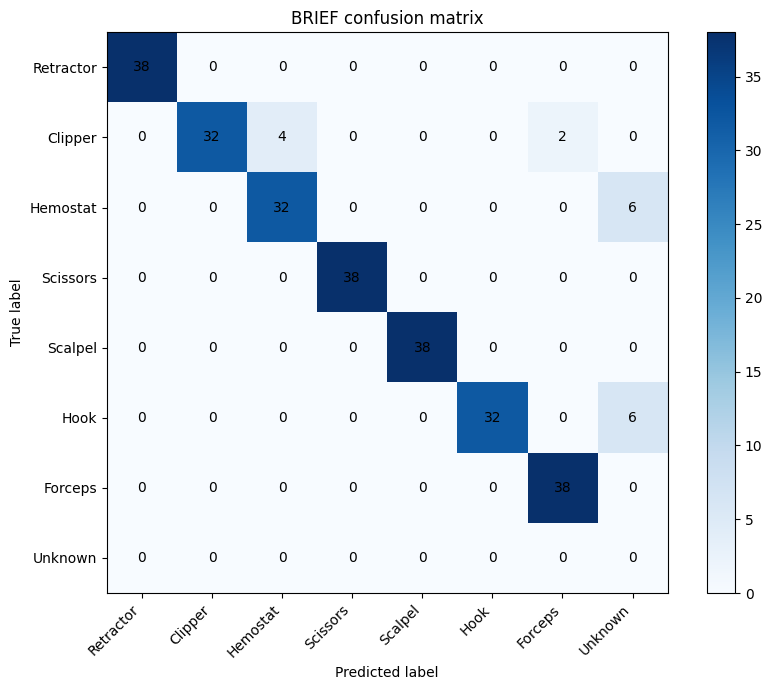

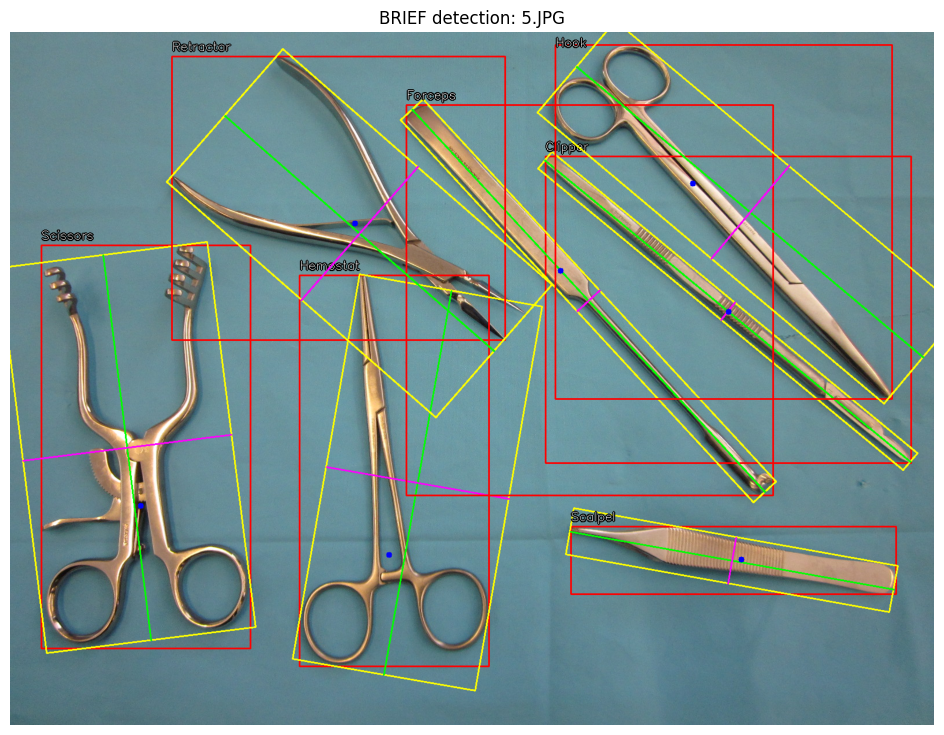

array([[[140, 132, 102],
        [139, 131, 101],
        [138, 130, 101],
        ...,
        [137, 132, 101],
        [132, 127,  96],
        [143, 138, 107]],

       [[139, 131, 101],
        [140, 132, 102],
        [139, 131, 102],
        ...,
        [144, 139, 108],
        [141, 136, 105],
        [147, 142, 111]],

       [[139, 131, 101],
        [141, 133, 103],
        [140, 132, 102],
        ...,
        [141, 136, 103],
        [138, 133, 100],
        [137, 132,  99]],

       ...,

       [[111, 101,  67],
        [113, 103,  69],
        [111, 101,  67],
        ...,
        [123, 116,  89],
        [115, 108,  81],
        [123, 116,  89]],

       [[111, 101,  67],
        [115, 105,  71],
        [115, 105,  71],
        ...,
        [124, 117,  90],
        [125, 118,  93],
        [121, 114,  89]],

       [[108,  98,  64],
        [115, 105,  71],
        [116, 106,  72],
        ...,
        [123, 116,  91],
        [125, 118,  93],
        [120, 113,  88]]

In [18]:
results, best_method = compare_methods(IMAGE_DIR, ANNOTATION_DIR)

plot_confusion_matrix(
    results[best_method]['y_true'],
    results[best_method]['y_pred'],
    title=f'{best_method} confusion matrix'
)

example_name = os.path.basename(get_image_paths(IMAGE_DIR)[0])
database = build_database_from_split(get_image_paths(IMAGE_DIR)[1:], ANNOTATION_DIR, method=best_method)
find_instruments(
    example_name,
    database,
    method=best_method,
    image_dir=IMAGE_DIR,
    display=True,
    save_path=f'final_output_{best_method}.jpg'
)

# Q2

In [ ]:
import cv2
import numpy as np
import os

# ============================================================
# IE 549 - HW2 - Question 2
# Background recovery from video with moving foreground
#
# Input : video file (example: 6p-c0.avi)
# Output: one image containing the recovered background
#
#
# Main idea:
# 1) Read video information
# 2) Define the valid time range:
#       [26 sec, total_duration - 42 sec]
# 3) Uniformly sample frames from only that valid range
# 4) Build an initial background estimate using temporal median
#    (median is much more robust than average for moving foreground)
# 5) Refine the background:
#       For each sampled frame, compare it with previous/next frames
#       to detect moving regions
#       Keep only stable pixels as valid background candidates
# 6) For every pixel, combine the valid candidates and choose a robust
#    final value
# 7) Fill any missing pixels using the initial median estimate
# 8) Save the final recovered background image
# ============================================================


# ------------------------------------------------------------
# Helper function:
# Read one frame from the video at a specific frame index
# ------------------------------------------------------------
def read_frame_at(cap, frame_index):
    """
    Jump to a specific frame and read it.

    Parameters
    ----------
    cap : cv2.VideoCapture
        OpenCV video capture object.
    frame_index : int
        Frame number to read.

    Returns
    -------
    frame : ndarray or None
        The BGR image if reading succeeds, else None.
    """
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    if not ok:
        return None
    return frame


# ------------------------------------------------------------
# Helper function:
# Build a list of uniformly spaced frame indices
# inside [start_idx, end_idx]
# ------------------------------------------------------------
def uniform_sample_indices(start_idx, end_idx, num_samples):
    """
    Generate uniformly spaced frame indices.

    Parameters
    ----------
    start_idx : int
        First valid frame index.
    end_idx : int
        Last valid frame index.
    num_samples : int
        Number of frames to sample.

    Returns
    -------
    indices : list[int]
        List of sampled frame indices.
    """
    if end_idx <= start_idx:
        return []

    # Use linspace so samples cover the whole valid interval
    indices = np.linspace(start_idx, end_idx, num_samples)

    # Convert to integer frame numbers
    indices = np.round(indices).astype(int)

    # Remove duplicates if the interval is short
    indices = np.unique(indices)

    return indices.tolist()


# ------------------------------------------------------------
# Helper function:
# Compute a motion mask using previous, current, and next frame
# ------------------------------------------------------------
def compute_motion_mask(prev_frame, curr_frame, next_frame,
                        diff_threshold=25,
                        blur_ksize=5):
    """
    Detect motion in the current frame by comparing it to
    both the previous and next frames.

    Why this helps:
    - Background is static
    - Foreground students are moving
    - If a pixel changes over time, it is likely foreground

    Parameters
    ----------
    prev_frame, curr_frame, next_frame : ndarray
        Consecutive BGR frames.
    diff_threshold : int
        Threshold used after absolute difference.
    blur_ksize : int
        Gaussian blur kernel size to reduce small noise.

    Returns
    -------
    motion_mask : ndarray (uint8)
        255 where motion is detected, 0 where likely stable.
    """
    # Convert all frames to grayscale because motion detection
    # does not need color
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)

    # Slight smoothing reduces sensor noise and tiny flicker
    prev_gray = cv2.GaussianBlur(prev_gray, (blur_ksize, blur_ksize), 0)
    curr_gray = cv2.GaussianBlur(curr_gray, (blur_ksize, blur_ksize), 0)
    next_gray = cv2.GaussianBlur(next_gray, (blur_ksize, blur_ksize), 0)

    # Difference with previous frame
    diff1 = cv2.absdiff(curr_gray, prev_gray)

    # Difference with next frame
    diff2 = cv2.absdiff(curr_gray, next_gray)

    # Pixels changing in either direction are suspicious
    motion_strength = cv2.max(diff1, diff2)

    # Threshold to obtain a binary motion mask
    _, motion_mask = cv2.threshold(motion_strength, diff_threshold, 255, cv2.THRESH_BINARY)

    # Morphological cleanup:
    # - open removes isolated noise
    # - close fills small holes inside moving objects
    kernel3 = np.ones((3, 3), np.uint8)
    kernel5 = np.ones((5, 5), np.uint8)

    motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel3)
    motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_CLOSE, kernel5)

    return motion_mask


# ------------------------------------------------------------
# Helper function:
# Build an initial robust background estimate using median
# ------------------------------------------------------------
def build_initial_background(frames):
    """
    Compute per-pixel temporal median from sampled frames.

    Why median and not average?
    - Average gets blurred / contaminated by moving people
    - Median is much more robust when foreground moves

    Parameters
    ----------
    frames : list[ndarray]
        List of sampled BGR frames.

    Returns
    -------
    bg_median : ndarray
        Initial background estimate.
    """
    # Stack frames into shape: (N, H, W, 3)
    stack = np.stack(frames, axis=0).astype(np.uint8)

    # Median across time axis
    bg_median = np.median(stack, axis=0).astype(np.uint8)

    return bg_median


# ------------------------------------------------------------
# Helper function:
# Refine background using motion masks + candidate selection
# ------------------------------------------------------------
def refine_background_with_candidates(frames,
                                      initial_bg,
                                      diff_to_bg_threshold=35,
                                      min_candidates_for_median=3):
    """
    Refine the initial background estimate.

    For each sampled frame:
    - Mark moving regions using prev/current/next frame comparison
    - For non-moving pixels, compare current pixel with initial background
    - If current pixel is close to the initial background and not moving,
      treat it as a valid background candidate for that location

    Final background for each pixel:
    - median of all valid candidates at that pixel
    - if not enough candidates, fall back to the initial background

    Parameters
    ----------
    frames : list[ndarray]
        Sampled BGR frames from the valid time region.
    initial_bg : ndarray
        Initial median background.
    diff_to_bg_threshold : int
        Pixel must be close enough to initial background to be accepted.
    min_candidates_for_median : int
        Minimum number of accepted candidates required before using
        candidate median at a pixel.

    Returns
    -------
    final_bg : ndarray
        Refined background image.
    """
    num_frames = len(frames)
    h, w, c = initial_bg.shape

    # We will store the sum of accepted pixels and how many times
    # each pixel was accepted. Later we can compute a robust estimate.
    #
    # Also keep candidates in a list for true per-pixel median where possible.
    # This is more memory-heavy, but still manageable for a moderate number
    # of sampled frames.
    accepted_masks = []
    accepted_frames = []

    # Process only frames that have a previous and next frame available
    for i in range(1, num_frames - 1):
        prev_frame = frames[i - 1]
        curr_frame = frames[i]
        next_frame = frames[i + 1]

        # Detect moving areas in the current frame
        motion_mask = compute_motion_mask(prev_frame, curr_frame, next_frame)

        # Convert motion mask into "stable mask"
        # stable == likely background
        stable_mask = (motion_mask == 0)

        # Compare the current frame to the initial background
        # If a pixel is very far from the background estimate,
        # it is suspicious even if motion is weak
        color_diff = np.linalg.norm(
            curr_frame.astype(np.float32) - initial_bg.astype(np.float32),
            axis=2
        )

        close_to_bg = (color_diff < diff_to_bg_threshold)

        # Accept pixel only if:
        # - it is stable over time
        # - it is also close to initial background estimate
        accept_mask = stable_mask & close_to_bg

        accepted_masks.append(accept_mask)
        accepted_frames.append(curr_frame)

    # Start with the initial median result
    final_bg = initial_bg.copy()

    # If there are no usable accepted frames, return the initial background
    if len(accepted_frames) == 0:
        return final_bg

    # Convert accepted frames to arrays for easier processing
    accepted_frames = np.stack(accepted_frames, axis=0)          # (K, H, W, 3)
    accepted_masks = np.stack(accepted_masks, axis=0)            # (K, H, W)

    # We now refine pixel by pixel:
    # if enough accepted candidates exist, use their median
    # otherwise keep the initial background pixel
    #
    # This loop is explicit for clarity in homework code.
    for y in range(h):
        for x in range(w):
            # Which sampled frames accepted this pixel as valid background?
            valid_ids = np.where(accepted_masks[:, y, x])[0]

            # Use candidate median only if enough valid observations exist
            if len(valid_ids) >= min_candidates_for_median:
                pixel_candidates = accepted_frames[valid_ids, y, x, :]   # shape: (M, 3)
                final_bg[y, x] = np.median(pixel_candidates, axis=0).astype(np.uint8)
            else:
                # Keep initial median estimate
                final_bg[y, x] = initial_bg[y, x]

    return final_bg


# ------------------------------------------------------------
# Main function required for the task
# ------------------------------------------------------------
def recover_background(video_path,
                       output_path='recovered_background.jpg',
                       skip_first_seconds=26,
                       skip_last_seconds=42,
                       num_samples=120,
                       show_result=True):
    """
    Recover a background image from the video by using only the
    middle segment of the video and rejecting moving foreground.

    Parameters
    ----------
    video_path : str
        Path to the input video file.
    output_path : str
        Output image filename.
    skip_first_seconds : int or float
        Ignore the first part of the video.
    skip_last_seconds : int or float
        Ignore the last part of the video.
    num_samples : int
        Number of frames to sample from the valid segment.
    show_result : bool
        Whether to display the final image.

    Returns
    -------
    final_bg : ndarray
        The recovered background image.
    """
    # Open the video
    cap = cv2.VideoCapture(video_path)

    # Make sure the file opened correctly
    if not cap.isOpened():
        raise FileNotFoundError(f'Could not open video: {video_path}')

    # Read basic video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Sanity check
    if fps <= 0 or frame_count <= 0:
        cap.release()
        raise ValueError('Could not read valid video metadata (fps or frame count).')

    # Compute total video duration
    total_duration = frame_count / fps

    # Convert time limits into frame indices
    start_frame = int(skip_first_seconds * fps)
    end_frame = int((total_duration - skip_last_seconds) * fps) - 1

    # Check that the usable interval is valid
    if end_frame <= start_frame:
        cap.release()
        raise ValueError(
            'The usable middle segment is empty. '
            'Check the video duration and the excluded time ranges.'
        )

    print('====================================================')
    print('Video information')
    print('----------------------------------------------------')
    print(f'FPS                : {fps:.3f}')
    print(f'Total frames       : {frame_count}')
    print(f'Total duration     : {total_duration:.3f} seconds')
    print(f'Ignore first       : {skip_first_seconds} seconds')
    print(f'Ignore last        : {skip_last_seconds} seconds')
    print(f'Valid start frame  : {start_frame}')
    print(f'Valid end frame    : {end_frame}')
    print('====================================================')

    # Uniformly sample frames only from the allowed middle segment
    sample_indices = uniform_sample_indices(start_frame, end_frame, num_samples)

    if len(sample_indices) < 3:
        cap.release()
        raise ValueError('Not enough sampled frames to build a background model.')

    print(f'Number of sampled frames: {len(sample_indices)}')

    # Read sampled frames into memory
    sampled_frames = []
    valid_indices = []

    for idx in sample_indices:
        frame = read_frame_at(cap, idx)
        if frame is not None:
            sampled_frames.append(frame)
            valid_indices.append(idx)

    # Release the video handle as soon as we are done reading
    cap.release()

    # Need at least 3 frames because motion refinement uses prev/curr/next
    if len(sampled_frames) < 3:
        raise ValueError('Could not read enough valid frames from the video.')

    print(f'Number of valid sampled frames actually loaded: {len(sampled_frames)}')

    # --------------------------------------------------------
    # STEP 1: Initial background estimate using temporal median
    # --------------------------------------------------------
    print('Building initial temporal median background...')
    initial_bg = build_initial_background(sampled_frames)

    # --------------------------------------------------------
    # STEP 2: Refine using motion masks and stable candidates
    # --------------------------------------------------------
    print('Refining background using motion rejection...')
    final_bg = refine_background_with_candidates(
        sampled_frames,
        initial_bg,
        diff_to_bg_threshold=35,
        min_candidates_for_median=3
    )

    # --------------------------------------------------------
    # Optional final cleanup:
    # A small median filter can slightly reduce isolated noise
    # while keeping edges relatively sharp.
    # --------------------------------------------------------
    final_bg = cv2.medianBlur(final_bg, 3)

    # Save the result
    cv2.imwrite(output_path, final_bg)
    print(f'Background image saved to: {output_path}. Press Esc to close the image window.')

    # Display result if requested
    if show_result:
        cv2.imshow('Recovered Background', final_bg)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    return final_bg


# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
if __name__ == '__main__':
    # Video filename given in the homework statement
    video_file = '6p-c0.avi'

    # Output filename for the recovered background
    output_image = 'recovered_background.jpg'

    # Run the background recovery pipeline
    recover_background(
        video_path=video_file,
        output_path=output_image,
        skip_first_seconds=26,
        skip_last_seconds=42,
        num_samples=120,
        show_result=True
    )

Video information
----------------------------------------------------
FPS                : 25.000
Total frames       : 2955
Total duration     : 118.200 seconds
Ignore first       : 26 seconds
Ignore last        : 42 seconds
Valid start frame  : 650
Valid end frame    : 1904
Number of sampled frames: 120
Number of valid sampled frames actually loaded: 120
Building initial temporal median background...
Refining background using motion rejection...
Background image saved to: recovered_background.jpg
